In [1]:
from pathlib import Path
import gzip
import json
from pprint import pprint
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np
from stable_platform_matchings.domain.instance import Instance
import seaborn as sns

In [2]:
sns.set_theme(context="paper", style="ticks")

In [3]:
instance = Instance.from_yaml(Path('../data/anon_14_day_instances/2020-08-27.yaml'))
LC_TO_USD = instance.lc_to_usd
TRUCK_FIXED_COST = instance.truck_fixed_cost

MAX_DEVIATION_POTENTIAL = 12

DEV_POT_BINS = np.linspace(2, 12, 7)
COST_BINS = np.linspace(65, 110, 7)

ZERO_TOL = 1e-8

def currency_formatter(x, pos):
    return f"${x:.0f}"


plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
})

In [4]:
LC_TO_USD

14500

In [7]:
root = Path("../results/exp_4_heuristic")
all_jsons = list(root.rglob("*.json.gz"))
graph_data_filename = "../data/graph_0-14960_00_new.pickle"

data = []

for file in all_jsons:
    with gzip.open(file, "rt", encoding="utf-8") as f:
        payload = json.load(f)

    metadata = payload["experiment_metadata"]
    summary = payload["runs"][0]["summary_vanilla"]

    snapshot = summary["instance_snapshot"]

    farmers = snapshot["farmers"]
    intermediaries = snapshot["intermediaries"]

    row = {
        "job_id": metadata["job_id"],
        "n_farmers": len(farmers),
        "n_intermediaries": len(intermediaries),
        "upper_bound": summary["forced_upper_bound"],
        "lower_bound": summary["forced_lower_bound"],
        "opt_gap": summary["rel_gap"],
        "time_suboptimal": summary["timestamps"][0],
        "time_vanilla": None,
    }

    data.append(row)

df = pd.DataFrame(data)

In [8]:
df.query("n_farmers == 25")

,job_id,n_farmers,n_intermediaries,upper_bound,lower_bound,opt_gap,time_suboptimal,time_vanilla
2,84,25,14,3.933763e+07,2.082725e+07,0.075956,13.354901,None
3,70,25,14,6.644183e+07,3.061094e+07,0.037505,7.002341,None
9,14,25,14,4.198282e+07,2.438661e+07,0.063842,13.793669,None
16,126,25,14,4.812739e+07,2.441653e+07,0.058680,12.528733,None
34,0,25,14,4.560731e+07,2.322806e+07,0.058099,11.268395,None
37,168,25,14,4.109694e+07,2.149605e+07,0.075082,11.548609,None
40,98,25,14,3.671861e+07,1.906069e+07,0.076194,12.361808,None
47,42,25,14,5.497793e+07,2.991956e+07,0.051227,17.387695,None
53,28,25,14,5.191782e+07,2.566388e+07,0.054993,9.306155,None
65,182,25,14,5.525626e+07,2.821140e+07,0.044251,17.465647,None


In [11]:
root = Path("../results/exp_4_exact")
all_jsons = list(root.rglob("*.json.gz"))

data_2 = []

for file in all_jsons:
    with gzip.open(file, "rt", encoding="utf-8") as f:
        payload = json.load(f)

    metadata = payload["experiment_metadata"]

    summary = payload["runs"][0]["summary_vanilla"]

    snapshot = summary["instance_snapshot"]

    farmers = snapshot["farmers"]
    intermediaries = snapshot["intermediaries"]

    row = {
        "job_id": metadata["job_id"],
        "n_farmers": len(farmers),
        "n_intermediaries": len(intermediaries),
        "opt_gap": summary["rel_gap"],
        "time_suboptimal": None,
        "time_vanilla": summary["timestamps"][0],
    }

    data_2.append(row)

df_2 = pd.DataFrame(data_2)

In [12]:
df.time_suboptimal.describe()

count      102.000000
mean      2117.983688
std       3160.175767
min          7.002341
25%        105.054697
50%        625.628829
75%       1989.498246
max      12125.965209
Name: time_suboptimal, dtype: float64

In [13]:
df_2.time_vanilla.describe()

count       90.000000
mean      2079.499968
std       3329.943488
min          9.059213
25%         95.082033
50%        491.736310
75%       1862.182819
max      11950.198272
Name: time_vanilla, dtype: float64

In [14]:
df_joint = pd.concat([df, df_2])

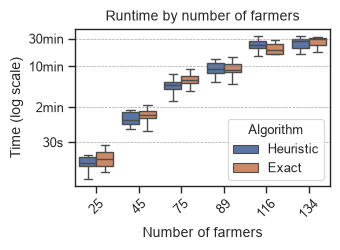

In [16]:
from matplotlib.ticker import FixedLocator, FixedFormatter

plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9
})


time_data_melted = df_joint.melt(id_vars='n_farmers', 
                                  value_vars=['time_suboptimal', 'time_vanilla'], 
                                  var_name='Time Type', 
                                  value_name='Time')

# Filter the DataFrame for n_farmers less or equal to 2400
time_data_filtered = time_data_melted[time_data_melted['n_farmers'] <= 134]

# Melt the DataFrame to reshape it for seaborn boxplot
time_data_filtered['Time'] = time_data_filtered['Time'] / 60/60  # Convert seconds to minutes


# Create the boxplot
plt.figure(figsize=(3.5, 2.6))
sns.boxplot(data=time_data_filtered, x='n_farmers', y='Time', hue='Time Type', showfliers=False)

# Set y-axis to log scale
plt.yscale('log')

# Define custom ticks and labels
ticks = [0.5/60, 2/60,  10/60, 30/60]  # 1 minute, 10 minutes, 1 hour, 2 hours in hours
# Filter ticks to include only those that have corresponding labels
labels = ['30s', '2min',  '10min', '30min']

# Draw horizontal lines at valid ticks
valid_ticks = [tick for tick, label in zip(ticks, labels) if label]

for tick in valid_ticks:
    plt.axhline(y=tick, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
plt.gca().yaxis.set_minor_locator(FixedLocator([]))  # Remove minor ticks
plt.gca().yaxis.set_major_locator(FixedLocator(valid_ticks))
#plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
plt.gca().yaxis.set_major_formatter(FixedFormatter(labels))

plt.title('Runtime by number of farmers')
plt.xlabel('Number of farmers')
plt.ylabel('Time (log scale)')
handles, labels = plt.gca().get_legend_handles_labels()
labels = ['Heuristic' if label == 'time_suboptimal' else 'Exact' if label == 'time_vanilla' else label for label in labels]
plt.legend(handles, labels, title='Algorithm', loc='lower right')
#plt.legend(title='Time Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



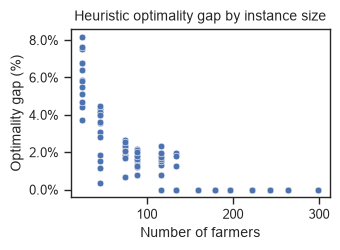

In [41]:
from matplotlib.ticker import PercentFormatter

# Filter the DataFrame for n_farmers less or equal to 2400
gap_data_filtered = df

# Create the boxplot for opt_gap
plt.figure(figsize=(3.5, 2.6))
sns.scatterplot(data=gap_data_filtered, x='n_farmers', y='opt_gap')

# Format y-axis as percentage
plt.gca().yaxis.set_major_formatter(PercentFormatter(xmax=1))

plt.title('Heuristic optimality gap by instance size')
plt.xlabel('Number of farmers')
plt.ylabel('Optimality gap (%)')
plt.tight_layout()
plt.show()